In [1]:
!pip install git+https://github.com/stanfordLINQS/SQcircuit.git@dev-ab

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Cloning https://github.com/stanfordLINQS/SQcircuit.git (to revision dev-ab) to /tmp/pip-req-build-aiqcpe1g
  Running command git clone -q https://github.com/stanfordLINQS/SQcircuit.git /tmp/pip-req-build-aiqcpe1g
  Running command git checkout -b dev-ab --track origin/dev-ab
  Switched to a new branch 'dev-ab'
  Branch 'dev-ab' set up to track remote branch 'dev-ab' from 'origin'.


In [2]:
import SQcircuit as sq
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

In this notebook, we demonstrate the basic optimization mechanics of SQcircuit by demonstrating the optimization problems of two simple but fundamental circuits: the LC resonator and the transmon qubit.

Beginning with the definition of each circuit as objects in SQcircuit, this notebook will show how to construct a loss function, obtain the gradient of the loss function with respect to the circuit element params (ex. capacitance), and update these values until a particular resonant frequency is obtained.

We start with the classic example of the LC resonator circuit, a single capacitor and inductor in parallel:

<div>
<img src="https://docs.google.com/uc?export=download&id=1wDlzECLRLaVgFR-oytB4WU8h5qg9tIDW" width="300"/>
</div>

First, we define the circuit in SQcircuit using arbitrary but somewhat realistic parameter values. The initial choice of parameter value is relatively insignificant in reaching an optimal final solution, but choosing them in the rough ballpark can help decrease training time:

In [3]:
# Define the circuit elements
cap_unit, ind_unit = 'pF', 'uH'
C = sq.Capacitor(7.746, cap_unit, Q=1e6)
L = sq.Inductor(81.67, ind_unit)

# Define the circuit
elements = {
  (0, 1): [C, L],
}
cr = sq.Circuit(elements)

To determine the resonant frequency of the circuit, we first need to solve for its lowest two eigenvalues by diagonalizing:

In [4]:
cr.set_trunc_nums([10,])
cr.diag(2)

(array([-1.38597232e-17,  6.32776158e-03]),
 [Quantum object: dims = [[10], [1]], shape = (10, 1), type = ket
  Qobj data =
  [[-2.18565964e-03+9.99997611e-01j]
   [ 1.66533454e-15-1.55431223e-15j]
   [ 2.08166817e-17+1.38777878e-17j]
   [ 5.55111512e-17+5.55111512e-17j]
   [ 8.32667268e-17+1.24900090e-16j]
   [-2.22044605e-16+5.55111512e-17j]
   [-2.22044605e-16+1.66533454e-16j]
   [ 4.16333634e-16+2.49800181e-16j]
   [-5.55111512e-17+5.13478149e-16j]
   [-6.78276879e-16+0.00000000e+00j]],
  Quantum object: dims = [[10], [1]], shape = (10, 1), type = ket
  Qobj data =
  [[ 5.53085620e-17+1.26830032e-15j]
   [-7.47458284e-01+6.64308748e-01j]
   [ 2.28983499e-16+9.71445147e-17j]
   [ 1.11022302e-16+2.49800181e-16j]
   [ 2.42861287e-17+8.32667268e-17j]
   [-1.24900090e-16+1.11022302e-16j]
   [ 2.77555756e-16-1.93715358e-31j]
   [-1.94289029e-16-1.94289029e-16j]
   [-1.11022302e-16+4.44089210e-16j]
   [-1.28369537e-16-5.55111512e-17j]]])

We define the resonant frequency as the first harmonic: the difference in frequency between the ground state and the first excited state.

For the parameters we have chosen, the initial first harmonic lies around 40MHz:

In [7]:
cr._efreqs
print(f"Fundamental resonant frequency: {(cr._efreqs[1] - cr._efreqs[0]) / 1e6} MHz")

Fundamental resonant frequency: 39.75849858406882 MHz


Next, we define our gradient and loss functions. 

We use the quadratic loss function $\mathcal{L}(\omega)=(\omega-\omega_\mathrm{target})^2$ to assess how close our circuit is to the right resonance frequency.

However, **loss functions must be normalized to be unitless**. This serves to eliminate dependence on unit scaling of many orders of magnitude, and ensure that the gradient magnitude is reasonable.

In this case, we normalize by the target frequency so that our loss function becomes:
$$\mathcal{L}(\omega)=\frac{(\omega-\omega_\mathrm{target})^2}{\omega_\mathrm{target}^2}$$

Autodifferentiation of the loss function will soon be supported in SQcircuit, but this loss function admits a straightforward analytical gradient $\frac{\partial\mathcal{L}}{\partial\omega}=\frac{2(\omega-\omega_\mathrm{target})}{\omega_\mathrm{target}^2}$ that we can code ourselves.

Beginning with our initial resonant frequency of 40MHz, we would like to modify the circuit parameters ($C$ and $L$) for a target $\omega$ of 20MHz:

In [8]:
N = 100 # Number of SGD iterations
omega_target = 20e6 # 20 MHz

cr.set_trunc_nums([10,])

def compute_loss(omega, omega_target):
  return (omega - omega_target)**2 / (omega_target)**2
def grad_dL_dw(omega, omega_target):
  return 2 * (omega - omega_target) / (omega_target)**2

As SQcircuit automatically computes the eigenfrequencies for a particular value of $L$ and $C$ in this circuit, we can express $\mathcal{L}(\omega)$ as a function of the parameter values $\mathcal{L}(C, L)$.

The actual optimization process uses stochastic gradient descent (SGD). This approach involves computing the gradients of the loss function $\frac{\partial\mathcal{L}}{\partial C}$ and $\frac{\partial\mathcal{L}}{\partial L}$ in each iteration, then updates $L$ and $C$ in the opposite (negative) direction, to follow the path that locally minimizes $\mathcal{L}$.

This occurs via the general SGD update rule:
$$
x\rightarrow x-\alpha\frac{\partial\mathcal{L}(x)}{\partial x}
$$
where $x$ can be any parameter (ex. $C$ or $L$).

While there are more sophisticated and powerful methods (ex. ADAM, RMSProp) that one can use with SQcircuit, this is one of the most straightforward and intuitive.

For a given circuit element (capacitor, inductor, junction, or loop) with parameter value $x$, SQcircuit provides the analytical (exact) gradient $\frac{\partial\omega}{\partial x}$ via the function `get_partial_omega`.

To compute the full loss function gradient $\frac{\partial\mathcal{L}}{\partial x}$, we can use our function `grad_dL_dw` to compute $\frac{\partial\mathcal{L}}{\partial\omega}$, then use the chain rule to multiply and compute:
$$
\frac{\partial\mathcal{L}}{\partial x}=\left(\frac{\partial\mathcal{L}}{\partial\omega}\right)\left(\frac{\partial\omega}{\partial x}\right)
$$
We do this in the following section:

In [15]:
def SGD(circuit, C, L, omega_target, num_steps,
        alpha = 1, verbose = False, k = 10):
  # Arrays to record loss and C/L param values
  loss_record = np.zeros((num_steps))
  C_record = np.zeros((num_steps))
  L_record = np.zeros((num_steps))
  C0 = C.get_value()
  l0 = L.get_value()
  C_previous = C.get_value(element_units = True)
  L_previous = L.get_value(element_units = True)
  for gradient_step in range(num_steps):
    ## Compute resonant frequency
    circuit.diag(2)
    omega = circuit._efreqs[1] - circuit._efreqs[0]
    ## Compute loss, dL/dw
    loss = compute_loss(omega, omega_target)
    dL_dw = grad_dL_dw(omega, omega_target)
    ## Compute dL/dC
    dw_dC = circuit.get_partial_omega(C, 1, subtract_ground = True)
    dL_dC = dw_dC * dL_dw
    dL_dC_scaled = dL_dC * C0 # Scale by initial value of C to normalize units
    ## Update C -> C - alpha * dL/dC (scaled to initial units)
    C_new = (C.get_value(element_units = True) - alpha * dL_dC_scaled)
    circuit.update_elements([C, ], [(C_new, C.unit)])
    ## Compute dL/dl (lowercase l indicates inductance, uppercase L loss)
    dw_dl = circuit.get_partial_omega(L, 1, subtract_ground = True)
    dL_dl = dw_dl * dL_dw
    dL_dl_scaled = dL_dl * l0 # Scale by initial value of l to normalize units
    ## Update l -> l - alpha * dL/dl (scaled to initial units)
    L_new = (L.get_value(element_units = True) - alpha * dL_dl_scaled)
    circuit.update_elements([L, ], [(L_new, L.unit)])
    ## Record updated values and loss
    loss_record[gradient_step] = loss
    C_record[gradient_step] = C_previous
    L_record[gradient_step] = L_previous
    # Optionally print values every k iterations
    if verbose and gradient_step % k == 0:
      print(f"SGD step {gradient_step} results:")
      print(f"Resonant frequency: {omega / 1e6} MHz")
      print(f"C value: {C_previous} {C.unit} -> {C_new} {C.unit}")
      print(f"dL_dC (unitless): {dL_dC_scaled}")
      print(f"L value: {L_previous} {L.unit} -> {L_new} {L.unit}")
      print(f"dL_dl (unitless): {dL_dl_scaled}\n")
    C_previous = C_new
    L_previous = L_new
  return loss_record, C_record, L_record

loss_record, C_record, L_record = SGD(cr, C, L, omega_target, num_steps = N, alpha = 5, verbose = True)

SGD step 0 results:
Resonant frequency: 20.000000000091898 MHz
C value: 51.534054698116 pF -> 51.53405469813897 pF
dL_dC (unitless): -4.594959317767333e-12
L value: 48.51161070357807 uH -> 48.51161070360104 uH
dL_dl (unitless): -4.594959318657944e-12

SGD step 10 results:
Resonant frequency: 20.000000000031932 MHz
C value: 51.53405469826562 pF -> 51.53405469827361 pF
dL_dC (unitless): -1.5966594216088742e-12
L value: 48.51161070372769 uH -> 48.51161070373568 uH
dL_dl (unitless): -1.596659421918285e-12

SGD step 20 results:
Resonant frequency: 20.000000000011255 MHz
C value: 51.534054698317775 pF -> 51.53405469832059 pF
dL_dC (unitless): -5.627050994715929e-13
L value: 48.511610703779844 uH -> 48.51161070378266 uH
dL_dl (unitless): -5.627050995806317e-13

SGD step 30 results:
Resonant frequency: 20.00000000000398 MHz
C value: 51.534054698335986 pF -> 51.53405469833698 pF
dL_dC (unitless): -1.9893050189845418e-13
L value: 48.511610703798056 uH -> 48.51161070379905 uH
dL_dl (unitless): -1

After less than 100 iterations, we are able to approach our desired target frequency of 20MHz to a precision better than 0.1%.

Let's take a look at the graph of our loss function, to see how this improves over time. $\mathcal{L}(L, C)$ varies smoothly and rapidly converges to an asymptotic minimum:

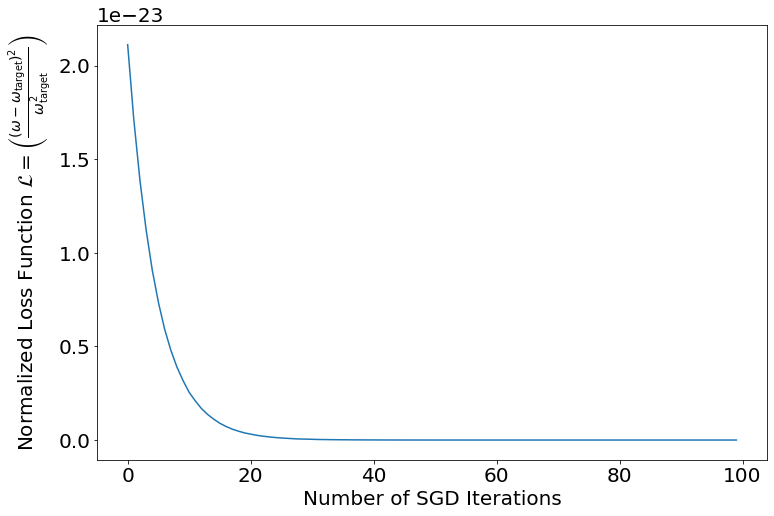

Final C value: 51.534054698345656 pF
Final L value: 48.511610703807726 uH


In [16]:
plt.figure(figsize=(12, 8))
plt.xlabel('Number of SGD Iterations')
plt.ylabel(r'Normalized Loss Function $\mathcal{L}=\left(\frac{(\omega - \omega_\mathrm{target})^2}{\omega_\mathrm{target}^2}\right)$')
plt.rc('font', size = 20)
plt.rc('axes', titlesize = 20)
plt.plot(np.arange(N), loss_record)
plt.show()
print(f"Final C value: {C.value} {cap_unit}")
print(f"Final L value: {L.value} {ind_unit}")

Let's now try selecting a set of five initial combinations of $(C, L)$ values in the range of 10-100 pF and $\mu$H, respectively and running SGD on each combination.

After running SGD on each combination for 100 iterations, we find that each initial setting converges to a different set of optimal $(C^*, L^*)$ values satisfying $\omega\approx$ 20 MHz. This demonstrates the efficiency of SGD in solving a non-convex optimization problem; there are an infinite set of local minima that each satisfy the condition $\omega=\frac{1}{\sqrt{LC}}=20$ MHz:

Trial 0 final resonant frequency: 20000000.007614188
Trial 1 final resonant frequency: 19999999.999999553
Trial 2 final resonant frequency: 20000000.000068486
Trial 3 final resonant frequency: 19999999.999992225
Trial 4 final resonant frequency: 20000000.000000015


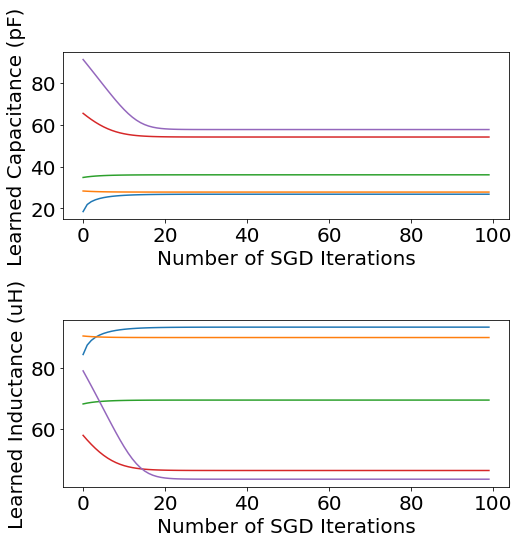

In [17]:
num_trials = 5
N = 100

fig, (ax_C, ax_L) = plt.subplots(2, figsize = (8, 8))
plt.subplots_adjust(hspace = 0.6)
for trial_idx in range(num_trials):
  C_init_val = np.random.uniform(10, 100)
  L_init_val = np.random.uniform(10, 100)
  C = sq.Capacitor(C_init_val, cap_unit, Q=1e6)
  L = sq.Inductor(L_init_val, ind_unit)
  elements = {
      (0, 1): [C, L],
  }
  cr = sq.Circuit(elements)
  cr.set_trunc_nums([10,])
  _, C_record, L_record = SGD(cr, C, L, omega_target, num_steps = N,
                              alpha = 10, verbose = False)
  omega = cr._efreqs[1] - cr._efreqs[0]
  print(f"Trial {trial_idx} final resonant frequency: {omega}")
  ax_C.plot(np.arange(N), C_record) # scale to pF
  ax_C.set_xlabel('Number of SGD Iterations')
  ax_C.set_ylabel(f'Learned Capacitance ({C.unit})')
  ax_L.plot(np.arange(N), L_record) # scale to uH
  ax_L.set_xlabel('Number of SGD Iterations')
  ax_L.set_ylabel(f'Learned Inductance ({L.unit})')
plt.rc('font', size = 14)
plt.rc('axes', titlesize = 14)
plt.show()

We can also consider the case of the transmon, consisting of a shunt capacitor in parallel with a Josephson junction rather than an inductor:

<div>
<img src="https://docs.google.com/uc?export=download&id=1oQJ9ggxPrADSbju7tg-3puaLJCqFpo8m" width="300"/>
</div>

The transmon also has a characteristic resonance given by the energy difference $\omega_1-\omega_0$ of its ground state and first excited level.

In [24]:
# Define the circuit elements
C = sq.Capacitor(100, 'uF')
J = sq.Junction(15, 'GHz')

# Define the circuit
elements = {
    (0, 1): [C, J],
}
circuit_transmon = sq.Circuit(elements)

In [25]:
cr.description()

H = ω_1ad_1a_1 
------------------------------------------------------------
mode 1:       harmonic       φ_1 = zp_1(a_1+ad_1)       ω_1/2π = 0.00318       zp_1 = 6.50e-01
------------------------------------------------------------
parameters:       
loops:            


In [26]:
circuit_transmon.set_trunc_nums([10,])
circuit_transmon.diag(2)
omega = circuit_transmon._efreqs[1] - circuit_transmon._efreqs[0]
print(f"Omega initial: {omega / 1e6} MHz")
print(f"C initial: {C.get_value() * 1e6} uF, J initial: {J.get_value() / 1e9} GHz")

Omega initial: 549.4774384763336 MHz
C initial: 99.99999999999999 uF, J initial: 15.0 GHz


In [27]:
# Learn resonant frequency of 5GHz

loss_record, C_record, J_record = SGD(circuit_transmon, C, J, omega_target = 900e6,
                                      num_steps = 100, alpha = 5, k = 10, verbose = True)

SGD step 0 results:
Resonant frequency: 549.477438476366 MHz
C value: 100 pF -> 99.99999967987088 pF
dL_dC (unitless): 6.402582242783979e-08
L value: 15.0 uH -> 17.377829793872973 uH
dL_dl (unitless): -0.47556595877459473

SGD step 10 results:
Resonant frequency: 879.8620184971008 MHz
C value: 99.99999878575692 pF -> 99.99999876736507 pF
dL_dC (unitless): 3.678367667830811e-09
L value: 24.019058873922503 uH -> 24.15566831839853 uH
dL_dl (unitless): -0.02732188889520525

SGD step 20 results:
Resonant frequency: 898.8430465152817 MHz
C value: 99.99999871599705 pF -> 99.99999871494042 pF
dL_dC (unitless): 2.113270536312032e-10
L value: 24.537215651013206 uH -> 24.54506404300866 uH
dL_dl (unitless): -0.0015696783990909475

SGD step 30 results:
Resonant frequency: 899.9335315028419 MHz
C value: 99.99999871198926 pF -> 99.99999871192855 pF
dL_dC (unitless): 1.2141016774074801e-11
L value: 24.566984438355178 uH -> 24.56743533878284 uH
dL_dl (unitless): -9.018008553250857e-05

SGD step 40 resu

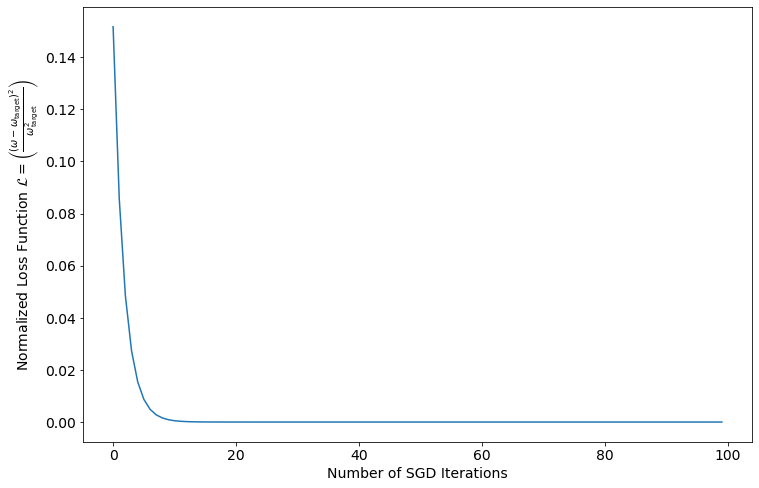

Final C value: 9.999999871174502e-14 pF
Final L value: 24.56879893976983 GHz


In [23]:
plt.figure(figsize=(12, 8))
plt.xlabel('Number of SGD Iterations')
plt.ylabel(r'Normalized Loss Function $\mathcal{L}=\left(\frac{(\omega - \omega_\mathrm{target})^2}{\omega_\mathrm{target}^2}\right)$')
plt.rc('font', size = 20)
plt.rc('axes', titlesize = 20)
plt.plot(np.arange(N), loss_record)
plt.show()
print(f"Final C value: {C.get_value() / 1e9} {cap_unit}")
print(f"Final L value: {J.get_value(angular_frequency = False) / 1e9} {J.unit}")